# Study 06 — What if frame-win probability changes over time?

In the earlier snooker model, a player had the same underlying probability of winning every frame.

For example:

\[
p = 0.58
\]

Study 05 relaxed our certainty about that number: there was still one fixed underlying \(p\), but we did not know exactly what it was.

This study changes a different assumption.

We will suppose that the player's true frame-win probability can itself change between periods.

There are several plausible reasons why this could happen. A developing player might genuinely improve over several seasons through practice and experience. An older player might decline as their scoring, concentration or consistency deteriorates. A longer-term injury, illness or other change in playing condition could also alter their underlying level for a period.

So a player who was genuinely a 62% frame player during one period might later be only a 54% frame player. The difference is not uncertainty about one hidden number: the underlying number itself has changed.

The distinction is important:

- **Parameter uncertainty:** there is one fixed \(p\), but we do not know its exact value.
- **Parameter variation / non-stationarity:** \(p\) itself changes over time.

We will keep frames independent and introduce no momentum or frame-to-frame dependence. The only change from the simple model is that the underlying value of \(p\) is no longer constant across time.

## A simple multi-period model

To isolate the effect of parameter variation, we will compare two players with the same average frame-win probability.

### Fixed model

The original model assumes:

\[
p = 0.58
\]

for every frame throughout the player's career.

### Varying model

Now suppose the player's underlying ability changes between five periods:

\[
p = 0.54,\ 0.58,\ 0.62,\ 0.60,\ 0.56
\]

These might loosely represent different stages of a career: development, improvement, a peak period, and later decline.

If the player spends the same amount of time in each period, the average frame-win probability is still:

\[
\frac{0.54 + 0.58 + 0.62 + 0.60 + 0.56}{5} = 0.58
\]

So both models describe a player who averages 58% across the whole observation period.

The difference is that one player is always a 58% frame player, while the other's true underlying probability changes over time.

This gives us a controlled comparison: the average strength is unchanged, but its distribution through time is different.

In [1]:
# Baseline: the player's frame-win probability is fixed over time.
p_fixed = 0.58

# Varying model: the player's true frame-win probability differs by period.
period_probabilities = [0.54, 0.58, 0.62, 0.60, 0.56]

# Check that both models have the same average frame strength.
p_average = sum(period_probabilities) / len(period_probabilities)

p_fixed, p_average

(0.58, 0.58)

## What does a period mean in the model?

Each period represents a stretch of time during which the player's underlying frame-win probability is reasonably stable.

In our simplified example, the player moves through five periods with true frame-win probabilities of:

\[
0.54,\ 0.58,\ 0.62,\ 0.60,\ 0.56
\]

Within any one period:

- the frame-win probability stays fixed;
- frames remain independent;
- winning or losing one frame does not affect the next.

The change happens **between periods**, not between individual frames.

So this is not a momentum model. It represents longer-term changes in the player's underlying level of performance.

For simplicity, we initially give each period equal weight. That keeps the player's overall average frame-win probability at 58%.

In [2]:
from math import comb


def match_win_probability(p, best_of):
    """Exact probability of winning a best-of-N match with independent frames."""
    frames_needed = best_of // 2 + 1

    # Sum the probabilities of every possible winning frame total.
    return sum(
        comb(best_of, wins) * p**wins * (1 - p)**(best_of - wins)
        for wins in range(frames_needed, best_of + 1)
    )

In [3]:
# Sanity-check the exact calculation for a best-of-11 match.
match_win_probability(p_fixed, best_of=11)

0.7076012138061588

In [4]:
# Calculate the best-of-11 match-win probability for each period.
period_match_win_probabilities = [
    match_win_probability(p, best_of=11)
    for p in period_probabilities
]

period_match_win_probabilities

[0.6071350799504199,
 0.7076012138061588,
 0.7957275412668245,
 0.75349813248,
 0.6585904206291706]

In [5]:
# Give each period equal weight and calculate the overall match-win probability.
varying_match_win_probability = (
    sum(period_match_win_probabilities) / len(period_match_win_probabilities)
)

varying_match_win_probability

0.7045104776265148

## Same average frame strength, different match probability

The fixed and varying models both have an average frame-win probability of 58%, but they do not produce exactly the same chance of winning a best-of-11 match.

- Fixed 58% model: about **70.76%**
- Five-period varying model: about **70.45%**

The difference is small, but it is real.

Averaging the frame probabilities first and then calculating the match probability is not the same as calculating the match probability separately within each period and then averaging those match probabilities.

This happens because match-win probability is a nonlinear function of \(p\).

So knowing a player's long-run average frame-win rate is not necessarily enough to reproduce their long-run match-win rate if their underlying ability has changed over time.

In [6]:
# Compare the fixed and varying models across several match lengths.
best_of_values = [3, 7, 11, 19, 35]

comparison = []

for best_of in best_of_values:
    fixed = match_win_probability(p_fixed, best_of)

    period_results = [
        match_win_probability(p, best_of)
        for p in period_probabilities
    ]
    varying = sum(period_results) / len(period_results)

    comparison.append((best_of, fixed, varying, varying - fixed))

comparison

[(3, 0.618976, 0.618592, -0.00038399999999993994),
 (7, 0.6705883933695999, 0.6690020389888, -0.0015863543807999037),
 (11, 0.7076012138061588, 0.7045104776265148, -0.0030907361796440602),
 (19, 0.7615393357559487, 0.7550689585955157, -0.006470377160432972),
 (35, 0.8313615084019516, 0.8181377319275127, -0.013223776474438842)]

## Parameter variation matters more in longer matches

The difference between the fixed and varying models becomes larger as the match gets longer.

| Match length | Fixed 58% model | Varying model | Difference |
|---|---:|---:|---:|
| Best of 3 | 61.90% | 61.86% | -0.04 pp |
| Best of 7 | 67.06% | 66.90% | -0.16 pp |
| Best of 11 | 70.76% | 70.45% | -0.31 pp |
| Best of 19 | 76.15% | 75.51% | -0.65 pp |
| Best of 35 | 83.14% | 81.81% | -1.32 pp |

For short matches, replacing the changing probabilities with their average makes almost no difference.

But as the match gets longer, the gap becomes more noticeable.

Under a fixed \(p=0.58\), longer matches increasingly magnify the stronger player's advantage. When the player's true strength varies over time, some matches are played during weaker periods, so the long-run match-win rate does not rise quite as quickly as the fixed-58% model predicts.

This is another example of why a long-run average \(p\) does not necessarily describe the underlying process well.

## Does more variation produce a larger effect?

So far we have compared one fixed model with one particular pattern of changing performance.

But the size of the changes in \(p\) should matter too.

We can test this while keeping the average frame-win probability fixed at 58%.

We will compare several five-period profiles:

- no variation;
- small variation around 58%;
- moderate variation;
- larger variation.

Each profile will still average 58%.

If non-stationarity itself matters, we should expect the match-win probability to move further away from the fixed model as the variation in \(p\) becomes larger.

In [7]:
# Create several performance profiles with the same 58% average.
performance_profiles = {
    "No variation": [0.58, 0.58, 0.58, 0.58, 0.58],
    "Small variation": [0.56, 0.58, 0.60, 0.59, 0.57],
    "Moderate variation": [0.54, 0.58, 0.62, 0.60, 0.56],
    "Larger variation": [0.50, 0.56, 0.66, 0.64, 0.54],
}

# Verify that every profile still averages 58%.
{
    name: sum(probabilities) / len(probabilities)
    for name, probabilities in performance_profiles.items()
}

{'No variation': 0.58,
 'Small variation': 0.58,
 'Moderate variation': 0.58,
 'Larger variation': 0.5800000000000001}

In [8]:
# Compare long-match win probability as the amount of variation increases.
profile_results = {}

for name, probabilities in performance_profiles.items():
    match_probabilities = [
        match_win_probability(p, best_of=35)
        for p in probabilities
    ]

    profile_results[name] = sum(match_probabilities) / len(match_probabilities)

profile_results

{'No variation': 0.8313615084019516,
 'Small variation': 0.8279735990502003,
 'Moderate variation': 0.8181377319275127,
 'Larger variation': 0.7755159780818471}

## More variation produces a larger difference

All four profiles have the same average frame-win probability of 58%.

But their best-of-35 match-win probabilities are:

- No variation: **83.14%**
- Small variation: **82.80%**
- Moderate variation: **81.81%**
- Larger variation: **77.55%**

As the player's underlying frame-win probability moves around more, the long-run match-win probability moves further away from the fixed 58% model.

So it is not only whether \(p\) changes that matters. The size of those changes matters too.

A long-run average of 58% can therefore hide very different underlying performance histories.

### What does that mean in terms of matches won?

Compared with the fixed 58% model, the effect can be expressed as expected wins over many best-of-35 matches:

- Small variation reduces the win probability by about **0.34 percentage points** — roughly **3 fewer wins per 1,000 matches**.
- Moderate variation reduces it by about **1.32 percentage points** — roughly **13 fewer wins per 1,000 matches**.
- Larger variation reduces it by about **5.59 percentage points** — roughly **56 fewer wins per 1,000 matches**.

So sufficiently large changes in underlying performance are not just a technical modelling detail. Two players can have the same long-run 58% frame-win rate while having materially different chances of winning long matches.

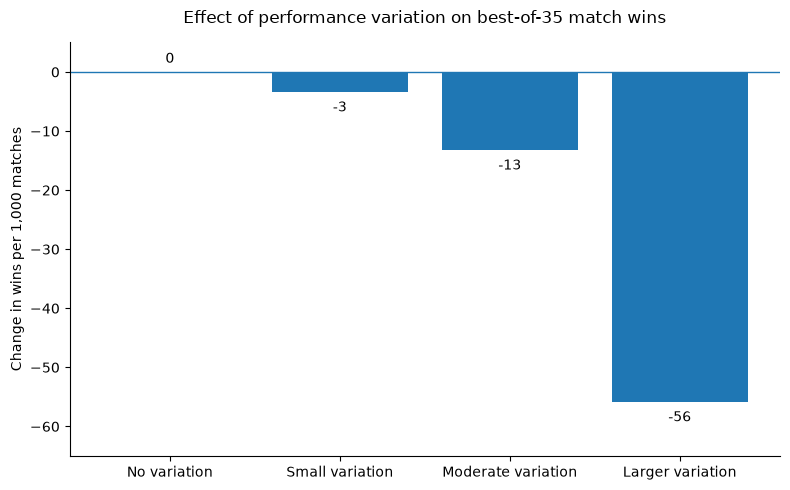

In [9]:
import matplotlib.pyplot as plt


# Show the change in expected wins relative to the fixed 58% model.
profile_names = list(profile_results.keys())
baseline = profile_results["No variation"]

change_in_wins_per_1000 = [
    (profile_results[name] - baseline) * 1000
    for name in profile_names
]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(profile_names, change_in_wins_per_1000)

ax.axhline(0, linewidth=1)
ax.set_ylim(-65, 5)

ax.set_ylabel("Change in wins per 1,000 matches")
ax.set_title(
    "Effect of performance variation on best-of-35 match wins",
    pad=14,
)

# Add readable labels without clipping them against the plot edges.
for bar, change in zip(bars, change_in_wins_per_1000):
    if change < 0:
        y = change - 1.5
        va = "top"
    else:
        y = 1
        va = "bottom"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y,
        f"{change:.0f}",
        ha="center",
        va=va,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [10]:
# Reverse the five periods while keeping exactly the same probabilities.
reversed_probabilities = list(reversed(period_probabilities))

original_result = sum(
    match_win_probability(p, best_of=35)
    for p in period_probabilities
) / len(period_probabilities)

reversed_result = sum(
    match_win_probability(p, best_of=35)
    for p in reversed_probabilities
) / len(reversed_probabilities)

original_result, reversed_result

(0.8181377319275127, 0.8181377319275127)

## The order of the periods does not matter here

Reversing the five periods produces exactly the same overall best-of-35 match-win probability:

\[
0.81814
\]

in both cases.

That follows from the assumptions of this study.

Each period contributes its own match-win probability, and we simply average those period results. Nothing that happens in one period changes the probability in another.

So the sequence

\[
0.54,\ 0.58,\ 0.62,\ 0.60,\ 0.56
\]

has the same overall result as

\[
0.56,\ 0.60,\ 0.62,\ 0.58,\ 0.54.
\]

The model therefore captures **variation in underlying performance**, but not trends, momentum or dependence between periods.

If we wanted the direction of change itself to matter, that would require another assumption and therefore a different study.

## Parameter uncertainty is not parameter variation

Study 05 and Study 06 both involve more than one possible value of \(p\), but for completely different reasons.

### Study 05 — parameter uncertainty

In Study 05, we assumed that the player has **one true frame-win probability**.

We simply do not know exactly what it is.

For example, after observing 58 wins from 100 frames, values such as 0.55, 0.58 or 0.61 might all be plausible estimates of the same underlying parameter.

When Monte Carlo draws different values of \(p\), those draws represent different possibilities for what the player's **single true value** might be.

They do not mean that the player's ability is actually changing.

### Study 06 — parameter variation

In this study, the different values are real features of the model.

The player might genuinely have:

\[
p = 0.54
\]

during one period and:

\[
p = 0.62
\]

during another.

There may be no uncertainty at all about those values in our simplified example. The important point is that the underlying parameter itself has changed.

So the distinction is:

- **Parameter uncertainty:** "There is one \(p\). We do not know exactly what it is."
- **Parameter variation:** "There is no single \(p\) that applies across all periods."

These are separate modelling problems and should not be confused.

## How does the effect grow with match length?

Earlier we found that the fixed and varying models were almost indistinguishable in very short matches, but the gap widened as the match became longer.

A graph makes that pattern easier to see.

We will plot the change in match-win probability produced by the five-period varying model relative to the fixed 58% model.

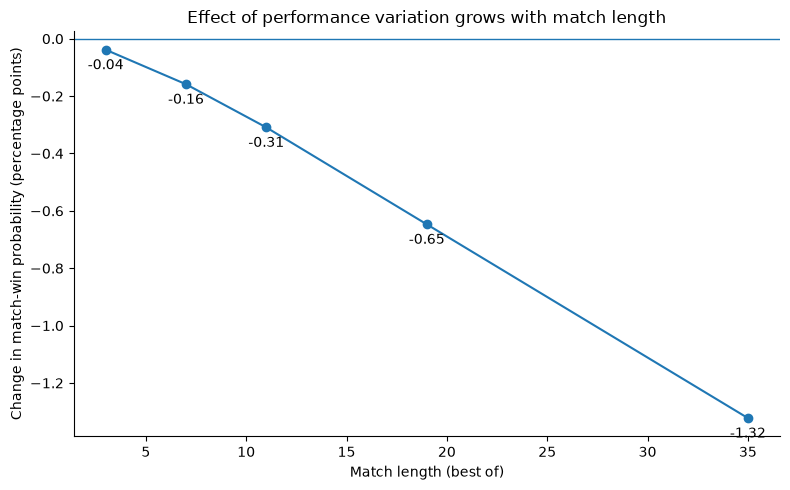

In [11]:
# Convert the fixed-versus-varying differences into percentage points.
match_lengths = [row[0] for row in comparison]
difference_percentage_points = [row[3] * 100 for row in comparison]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    match_lengths,
    difference_percentage_points,
    marker="o",
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("Match length (best of)")
ax.set_ylabel("Change in match-win probability (percentage points)")
ax.set_title("Effect of performance variation grows with match length")

# Label each point with the size of the difference.
for best_of, difference in zip(
    match_lengths,
    difference_percentage_points,
):
    ax.annotate(
        f"{difference:.2f}",
        (best_of, difference),
        xytext=(0, -14),
        textcoords="offset points",
        ha="center",
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### What the graph shows

The effect of parameter variation is almost negligible in very short matches, but it grows steadily with match length.

Compared with treating the player as a constant 58% frame player, the five-period model changes the estimated match-win probability by approximately:

- **-0.04 percentage points** in a best-of-3;
- **-0.16 points** in a best-of-7;
- **-0.31 points** in a best-of-11;
- **-0.65 points** in a best-of-19;
- **-1.32 points** in a best-of-35.

This connects directly to Study 03.

Longer matches magnify a genuine advantage when \(p\) is fixed. But if the player's underlying strength changes over time, using one long-run average value of \(p\) increasingly hides those differences.

The longer the match, the more consequential that simplification becomes.

## Why does variation reduce the match-win probability here?

Our examples consistently produced a lower overall match-win probability than the fixed 58% model.

The reason is that, in long matches, the benefit of becoming stronger above 58% is smaller than the damage caused by becoming equally weaker below 58%.

For example, in a best-of-35 match:

- moving from 58% to 60% increases match-win probability by about **5.43 percentage points**;
- moving from 58% to 56% decreases it by about **6.79 percentage points**.

So the gains and losses are not symmetrical.

Once the player is already favoured to win each frame, increasing \(p\) further produces diminishing gains in match-win probability. Moving \(p\) downward towards 50%, however, removes the stronger player's long-match advantage more quickly.

When we average across stronger and weaker periods, the weaker periods therefore pull the overall match-win rate down by more than the stronger periods push it up.

This is why a fixed model based only on the average \(p\) can overstate the long-run match-win probability.

In [12]:
# Check the asymmetry around the fixed 58% baseline in a best-of-35 match.
p_lower = 0.56
p_middle = 0.58
p_higher = 0.60

win_lower = match_win_probability(p_lower, best_of=35)
win_middle = match_win_probability(p_middle, best_of=35)
win_higher = match_win_probability(p_higher, best_of=35)

gain_from_higher_p = (win_higher - win_middle) * 100
loss_from_lower_p = (win_lower - win_middle) * 100

win_lower, win_middle, win_higher, gain_from_higher_p, loss_from_lower_p

(0.7635036964759755,
 0.8313615084019516,
 0.885687383236963,
 5.43258748350115,
 -6.785781192597606)

### The weaker period hurts more than the stronger period helps

For a best-of-35 match:

- at \(p = 0.56\), match-win probability is about **76.35%**;
- at \(p = 0.58\), it is about **83.14%**;
- at \(p = 0.60\), it is about **88.57%**.

So moving two percentage points above 58% increases the chance of winning the match by about **5.43 percentage points**.

But moving two percentage points below 58% decreases it by about **6.79 percentage points**.

The changes in frame strength are symmetrical:

$$
0.56 \leftarrow 0.58 \rightarrow 0.60
$$

But their effects on match-win probability are not.

That asymmetry explains why variation around 58% lowers the average match-win probability in our examples. The weaker periods do more damage than equally stronger periods provide benefit.

It also explains why the effect becomes more visible in longer matches: match length magnifies the nonlinear relationship between frame strength and match outcomes.

## Conclusions

Study 06 changed one assumption from the simple snooker model: the player's true frame-win probability was allowed to vary between periods rather than remaining fixed forever.

The main findings are:

- A long-run average frame-win probability does not necessarily produce the same long-run match-win probability as a fixed model using that average.
- The difference is small when the variation in \(p\) is small, but becomes larger as the underlying performance varies more.
- The effect also grows with match length. In our five-period example, the gap was almost negligible in a best-of-3 but reached about **1.32 percentage points** in a best-of-35.
- In the larger-variation profile, the fixed 58% model implied about **56 more wins per 1,000 best-of-35 matches** than the varying model.
- The order of the periods did not matter because this study introduced no momentum or dependence between periods.
- The downward effect occurred because match-win probability is nonlinear in \(p\): around 58%, equally sized improvements and declines in frame strength do not have equally sized effects on the chance of winning a long match.

Most importantly, this study separates two ideas that are easy to confuse:

- **Parameter uncertainty:** there is one true \(p\), but we do not know exactly what it is.
- **Parameter variation / non-stationarity:** the true value of \(p\) itself changes over time.

A player's historical average frame-win rate can therefore be a useful summary while still hiding meaningful changes in the process that produced it.

The simple fixed-\(p\) model remains useful, but its interpretation becomes weaker when performance is not stable over time.